<a href="https://colab.research.google.com/github/JosephBless/Deep-Learning-Colab/blob/main/Chap_20%EF%BC%9A%E6%8A%95%E8%B3%87%E6%83%85%E7%B7%92%E7%9A%84%E8%A7%A3%E8%AE%80_%E7%B5%90%E5%90%88%E6%83%85%E7%B7%92%E5%88%86%E6%9E%90%E7%9A%84%E4%BA%A4%E6%98%93%E7%AD%96%E7%95%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

在昨天中我們學會了[基本的 NLP 技術來分析文字的情緒](https://colab.research.google.com/drive/1WTiHoYKFnq95HdyUrPK2bWBONsFDjRR5)，在本課中，我們將學習如何將情緒指標納入交易決策，並評估策略的性能。我們將使用從 `CNBC` 新聞中提取的情緒數據，結合技術分析，構建一個完整的交易策略。最後，我們將使用回測的方法評估策略的有效性。[今日 Colab](https://colab.research.google.com/drive/1qJ7FMgLuRF4HFUSaXY1ssZ4rnqROcVU2?usp=sharing)

---

## **一、引言**

### **1. 為什麼將情緒分析納入交易策略？**

- **補充技術分析**：情緒分析可以提供市場技術指標無法捕捉的資訊。
- **預測市場走勢**：投資者情緒可能會提前反映在市場價格中，例如看到特定新聞可能會影響投資者決定。
- **分散風險**：結合情緒指標可以使交易決策更加全面，降低單一指標的風險。
![https://ithelp.ithome.com.tw/upload/images/20241007/201205495ghWsF9MRP.jpg](https://ithelp.ithome.com.tw/upload/images/20241007/201205495ghWsF9MRP.jpg)
---

## **二、環境設置**

### **1. 安裝必要的庫**

我們需要以下 Python 庫：

- **Pandas**：數據處理和分析。
- **NumPy**：科學計算。
- **Matplotlib**：數據可視化。
- **NLTK**：自然語言處理工具包。
- **NewsAPI**：用於獲取新聞文章的 API。今日新介紹這個 API，也可以用昨日介紹的!
- **YFinance**：獲取金融數據。
- **Backtrader**：回測框架。

In [ ]:
!pip install pandas numpy matplotlib
!pip install nltk
!pip install newsapi-python
!pip install yfinance
!pip install backtrader

### **2. 導入庫**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from newsapi import NewsApiClient
import yfinance as yf
import backtrader as bt
import datetime

### **3. 下載 NLTK 資源**


In [ ]:
nltk.download('vader_lexicon')
nltk.download('punkt')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## **三、數據準備**

### **1. 獲取歷史股價數據**

因為今天我們用的[newsapi](https://newsapi.org/)免費版本身只能抓到最近一個月，因此我們今天的例子會是一個月的股價例子，若是讀者有升級帳號等即可在自行更改範圍。我們將使用 `yfinance` 獲取蘋果公司（AAPL）的歷史股價數據，日期範圍為 **2024-09-07** 至 **2024-10-05**。

In [ ]:
# 定義日期範圍
start_date = '2024-09-07'
end_date = '2024-10-05'

# 獲取數據
data = yf.download('AAPL', start=start_date, end=end_date)
data.reset_index(inplace=True)
data['Date'] = pd.to_datetime(data['Date'])

[*********************100%***********************]  1 of 1 completed


### **2. 獲取情緒數據**
​
#### **(1) 使用 NewsAPI 獲取新聞文章**
![https://ithelp.ithome.com.tw/upload/images/20241007/201205492yJrHz1pMa.png](https://ithelp.ithome.com.tw/upload/images/20241007/201205492yJrHz1pMa.png)
​
為了遵守網站的服務條款，我們將使用 **NewsAPI** 這個合法的新聞 API 來獲取 CNBC 的新聞文章。
​
您需要在 [NewsAPI 官方網站](https://newsapi.org/) 註冊一個免費帳戶，並獲取您的 API 金鑰。

In [ ]:
# 替換為您的 NewsAPI API 金鑰
newsapi = NewsApiClient(api_key='YOUR_NEWSAPI_KEY')

#### **(2) 定義函數以在特定日期範圍內獲取新聞**


In [ ]:
def get_news_sentiments(keyword, from_date, to_date):
    all_articles = newsapi.get_everything(
        q=keyword,
        domains='cnbc.com',
        from_param=from_date,
        to=to_date,
        language='en',
        sort_by='publishedAt',
        page_size=100
    )

    articles = all_articles['articles']
    sia = SentimentIntensityAnalyzer()
    sentiments = []

    for article in articles:
        published_at = article['publishedAt'][:10]
        title = article['title'] or ''
        description = article['description'] or ''
        text = title + ' ' + description
        score = sia.polarity_scores(text)['compound']
        sentiments.append({'Date': published_at, 'Sentiment': score})

    sentiment_df = pd.DataFrame(sentiments)
    sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date'])
    return sentiment_df

#### **(3) 獲取指定日期範圍內的新聞情緒**


In [ ]:
# 獲取新聞情緒數據
sentiment_data = get_news_sentiments('Apple', start_date, end_date)

In [ ]:
sentiment_data

,Date,Sentiment
0,2024-10-04,-0.6249
1,2024-10-04,0.8176
2,2024-10-03,0.5267
3,2024-10-03,-0.8126
4,2024-10-03,-0.8720
...,...,...
86,2024-09-09,0.0000
87,2024-09-09,0.4033
88,2024-09-09,0.0000
89,2024-09-08,0.8316


### **3. 合併股價數據和情緒數據**

In [ ]:
# 按日期計算平均情緒得分
daily_sentiment = sentiment_data.groupby('Date').mean().reset_index()

# 合併數據
merged_data = pd.merge(data, daily_sentiment, on='Date', how='left')
merged_data['Sentiment'].fillna(0, inplace=True)

<ipython-input-25-d0013db9ab10>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data['Sentiment'].fillna(0, inplace=True)


## **四、將情緒指標納入交易策略**

### **1. 定義交易策略**

我們將在 `Backtrader` 中定義一個自訂策略，該策略將結合情緒指標和移動平均線進行交易決策。

In [ ]:
class SentimentStrategy(bt.Strategy):
    params = (
        ('short_window', 5),
        ('long_window', 10),
        ('sentiment_threshold', 0.05),
    )

    def __init__(self):
        # 定義移動平均線
        self.sma_short = bt.indicators.SimpleMovingAverage(self.datas[0].close, period=self.params.short_window)
        self.sma_long = bt.indicators.SimpleMovingAverage(self.datas[0].close, period=self.params.long_window)

        # 獲取情緒指標
        self.sentiment = self.datas[0].sentiment

        # 記錄交易訊號
        self.order = None

    def next(self):
        if self.order:
            return  # 如果有未完成的訂單，則不執行新的交易

        if not self.position:
            # 買入條件
            if self.sma_short[0] > self.sma_long[0] and self.sentiment[0] > self.params.sentiment_threshold:
                self.order = self.buy()
        else:
            # 賣出條件
            if self.sma_short[0] < self.sma_long[0] or self.sentiment[0] < -self.params.sentiment_threshold:
                self.order = self.sell()

    def notify_order(self, order):
        if order.status in [order.Completed]:
            if order.isbuy():
                print(f"買入: {order.executed.price}, 日期: {self.data.datetime.date(0)}")
            elif order.issell():
                print(f"賣出: {order.executed.price}, 日期: {self.data.datetime.date(0)}")
            self.bar_executed = len(self)
        self.order = None  # 重置訂單變量

### **2. 設置數據饋入**

Backtrader 需要將數據封裝為特定的格式。

In [ ]:
# 自訂數據饋入類，包含情緒指標
class PandasData_Sentiment(bt.feeds.PandasData):
    lines = ('sentiment',)
    params = (
        ('sentiment', -1),
    )

### **3. 準備數據**


In [ ]:
# 將數據設置為索引
merged_data.set_index('Date', inplace=True)

# 創建數據饋入
data_feed = PandasData_Sentiment(dataname=merged_data)

### **4. 執行回測**


In [ ]:
# 設置 Cerebro
cerebro = bt.Cerebro()
cerebro.adddata(data_feed)
cerebro.addstrategy(SentimentStrategy)
cerebro.broker.setcash(100000.0)
cerebro.broker.setcommission(commission=0.001)

print('初始資金: %.2f' % cerebro.broker.getvalue())
cerebro.run()
print('最終資金: %.2f' % cerebro.broker.getvalue())

初始資金: 100000.00
買入: 227.33999633789062, 日期: 2024-09-23
賣出: 228.64999389648438, 日期: 2024-09-24
買入: 224.92999267578125, 日期: 2024-09-25
賣出: 227.3000030517578, 日期: 2024-09-26
買入: 228.4600067138672, 日期: 2024-09-27
賣出: 227.89999389648438, 日期: 2024-10-04
最終資金: 100001.76


### **5. 繪製結果**


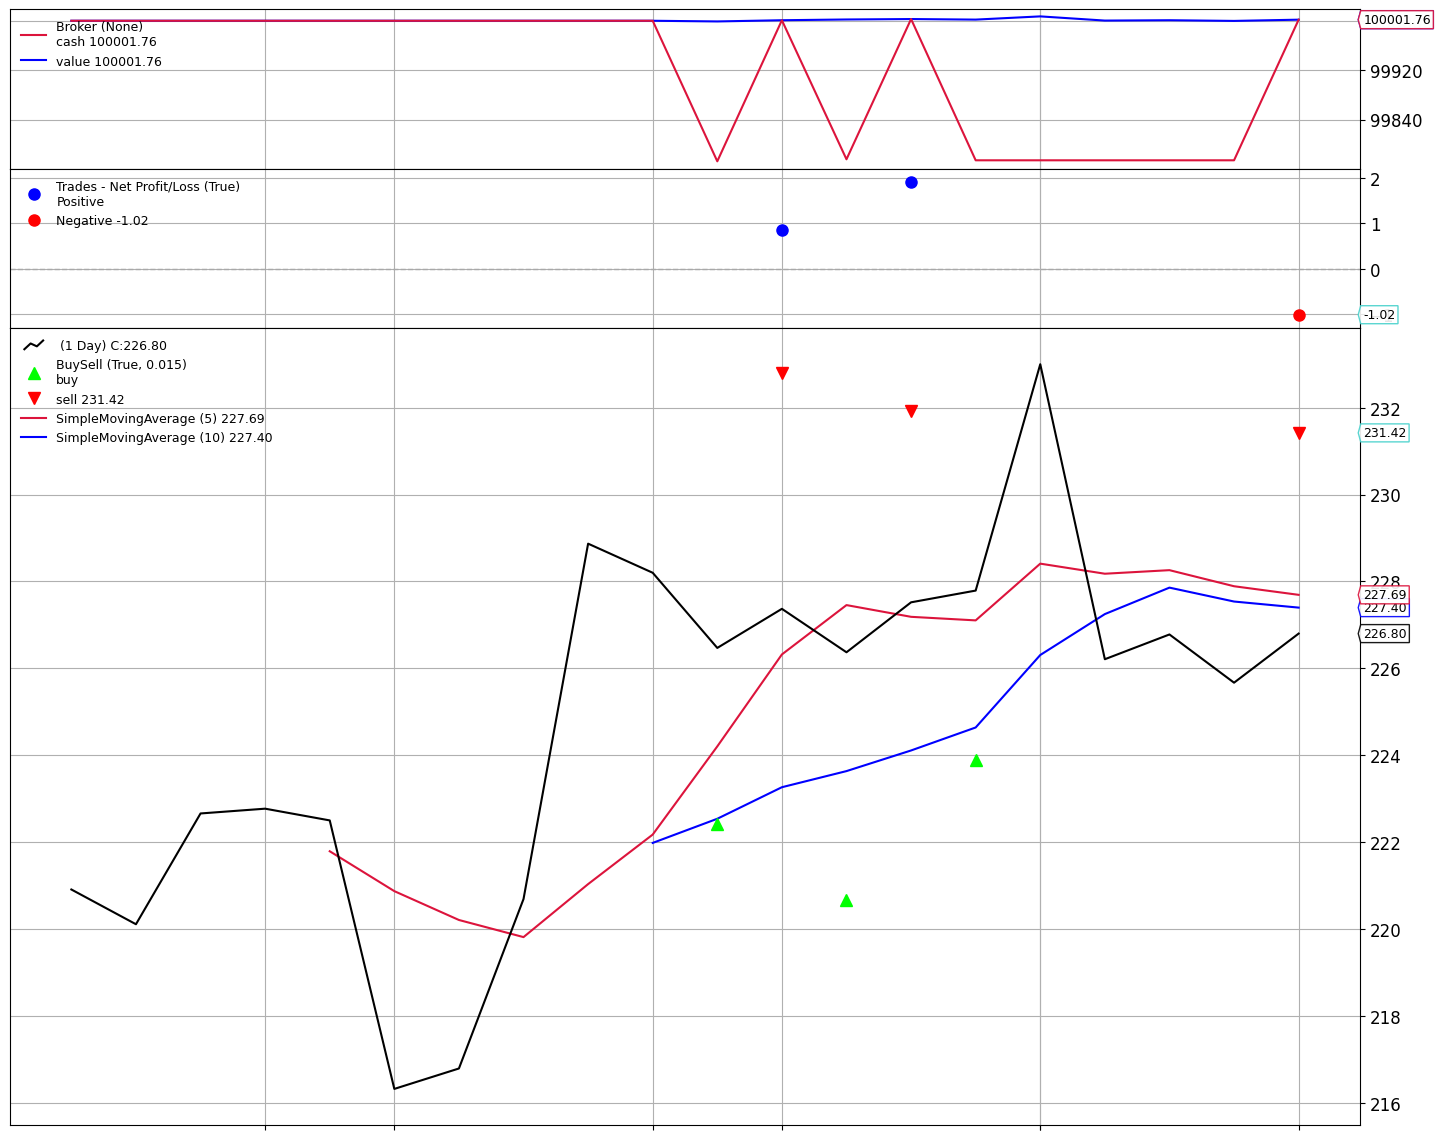

In [ ]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 12]
plt.rcParams.update({'font.size': 12})
img = cerebro.plot(iplot = False)
img[0][0].savefig('backtrader_sentiment.png')

## **五、評估策略性能**

### **1. 計算策略績效指標**

In [ ]:
# 計算總收益
final_value = cerebro.broker.getvalue()
profit = final_value - 100000.0
print(f"總收益: {profit:.2f}")

# 計算年化收益率
days = (merged_data.index[-1] - merged_data.index[0]).days
if days > 0:
    cagr = (final_value / 100000.0) ** (365.0 / days) - 1
    print(f"年化收益率: {cagr:.2%}")
else:
    print("日期範圍不足以計算年化收益率。")

總收益: 1.76
年化收益率: 0.03%


### **2. 比較基準表現**


In [ ]:
# 持有收益
initial_price = merged_data['Close'][0]
final_price = merged_data['Close'][-1]
hold_return = (final_price / initial_price) - 1
print(f"持有期間的收益率: {hold_return:.2%}")

持有期間的收益率: 2.67%


<ipython-input-34-056da4370c14>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  initial_price = merged_data['Close'][0]
<ipython-input-34-056da4370c14>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_price = merged_data['Close'][-1]


### **3. 分析結果**

- **超額收益**：比較策略收益與持有收益，判斷策略是否產生超額收益。
- **風險調整後收益**：考慮策略的波動性，計算夏普比率等指標。

---

## **六、總結**

在本課中，我們：

- **獲取了歷史股價和新聞情緒數據**，並將其合併為一個數據集。
- **使用 NewsAPI 在指定時間區間內搜尋了 CNBC 新聞**，以對應股價數據。
- **定義了一個結合情緒指標的交易策略**，並在 Backtrader 中實現。
- **執行了回測**，並評估了策略的性能。
- **討論了策略的改進方向**，包括調整參數和引入其他技術指標。

---

## **七、作業**

1. **擴展新聞數據集**：嘗試調整關鍵詞，或者增加其他新聞來源，豐富情緒數據。
2. **優化策略參數**：調整移動平均線的週期和情緒閾值，尋找最佳組合。
3. **比較不同的情緒分析方法**：使用 TextBlob 或其他情緒分析工具，對比結果。
4. **添加風險管理措施**：實現止損止盈機制，評估對策略的影響。

---

## **提示**

- **API 限制**：注意 NewsAPI 的免費帳戶有每日請求限制，請合理使用。
- **數據質量**：確保情緒數據的可靠性，過少的新聞可能導致情緒指標不準確。
- **時間同步**：確保情緒數據和股價數據的日期對齊，避免數據錯位。

---

## **注意事項**

- **API 金鑰安全性**：請勿將您的 API 金鑰公開分享，確保金鑰的安全。
- **合規要求**：遵守各數據來源的使用條款和法律法規。
- **倫理考慮**：使用官方 API 獲取數據，避免違反網站的服務條款。
- **風險提示**：回測結果不代表未來表現，投資需謹慎。

---

*希望通過本課的學習，能夠掌握將情緒分析納入交易策略的方法，並能夠獨立評估和改進策略性能。*

---

## **完整程式碼**

In [ ]:
# 安裝必要的庫
!pip install pandas numpy matplotlib
!pip install nltk
!pip install newsapi-python
!pip install yfinance
!pip install backtrader

# 導入庫
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from newsapi import NewsApiClient
import yfinance as yf
import backtrader as bt
import datetime

# 下載 NLTK 資源
nltk.download('vader_lexicon')
nltk.download('punkt')

# 替換為您的 NewsAPI API 金鑰
newsapi = NewsApiClient(api_key='Your_News_API_key')

# 定義日期範圍
start_date = '2024-09-07'
end_date = '2024-10-05'

# 獲取 AAPL 歷史數據
data = yf.download('AAPL', start=start_date, end=end_date)
data.reset_index(inplace=True)
data['Date'] = pd.to_datetime(data['Date'])

# 定義函數以在特定日期範圍內獲取新聞
# 定义函数以在特定日期范围内获取新闻
def get_news_sentiments(keyword, from_date, to_date):
    all_articles = newsapi.get_everything(
        q=keyword,
        domains='cnbc.com',
        from_param=from_date,
        to=to_date,
        language='en',
        sort_by='publishedAt',
        page_size=100
    )

    articles = all_articles['articles']
    sia = SentimentIntensityAnalyzer()
    sentiments = []

    for article in articles:
        published_at = article['publishedAt'][:10]
        text = article['title'] + ' ' + (article['description'] or '')
        score = sia.polarity_scores(text)['compound']
        sentiments.append({'Date': published_at, 'Sentiment': score})

    sentiment_df = pd.DataFrame(sentiments)
    sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date'])
    return sentiment_df


# 獲取新聞情緒數據
sentiment_data = get_news_sentiments('Apple', start_date, end_date)

# 按日期計算平均情緒得分
daily_sentiment = sentiment_data.groupby('Date').mean().reset_index()

# 合併數據
merged_data = pd.merge(data, daily_sentiment, on='Date', how='left')
merged_data['Sentiment'].fillna(0, inplace=True)

# 自訂數據饋入類，包含情緒指標
class PandasData_Sentiment(bt.feeds.PandasData):
    lines = ('sentiment',)
    params = (
        ('sentiment', -1),
    )

# 將數據設置為索引
merged_data.set_index('Date', inplace=True)

# 創建數據饋入
data_feed = PandasData_Sentiment(dataname=merged_data)

# 定義交易策略
class SentimentStrategy(bt.Strategy):
    params = (
        ('short_window', 5),
        ('long_window', 10),
        ('sentiment_threshold', 0.05),
    )

    def __init__(self):
        # 定義移動平均線
        self.sma_short = bt.indicators.SimpleMovingAverage(self.datas[0].close, period=self.params.short_window)
        self.sma_long = bt.indicators.SimpleMovingAverage(self.datas[0].close, period=self.params.long_window)

        # 獲取情緒指標
        self.sentiment = self.datas[0].sentiment

    def next(self):
        if not self.position:
            # 買入條件
            if self.sma_short[0] > self.sma_long[0] and self.sentiment[0] > self.params.sentiment_threshold:
                self.buy()
        else:
            # 賣出條件
            if self.sma_short[0] < self.sma_long[0] or self.sentiment[0] < -self.params.sentiment_threshold:
                self.sell()

# 設置 Cerebro
cerebro = bt.Cerebro()
cerebro.adddata(data_feed)
cerebro.addstrategy(SentimentStrategy)
cerebro.broker.setcash(100000.0)
cerebro.broker.setcommission(commission=0.001)

print('初始資金: %.2f' % cerebro.broker.getvalue())
cerebro.run()
print('最終資金: %.2f' % cerebro.broker.getvalue())

# 繪製結果
%matplotlib inline
cerebro.plot(iplot=True, volume=False)

# 計算策略績效指標
final_value = cerebro.broker.getvalue()
profit = final_value - 100000.0
print(f"總收益: {profit:.2f}")

days = (merged_data.index[-1] - merged_data.index[0]).days
if days > 0:
    cagr = (final_value / 100000.0) ** (365.0 / days) - 1
    print(f"年化收益率: {cagr:.2%}")
else:
    print("日期範圍不足以計算年化收益率。")

# 持有收益
initial_price = merged_data['Close'][0]
final_price = merged_data['Close'][-1]
hold_return = (final_price / initial_price) - 1
print(f"持有期間的收益率: {hold_return:.2%}")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[*********************100%***********************]  1 of 1 completed


初始資金: 100000.00
最終資金: 100001.76


<ipython-input-10-eb28752d6ac5>:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data['Sentiment'].fillna(0, inplace=True)


<IPython.core.display.Javascript object>

總收益: 1.76
年化收益率: 0.03%
持有期間的收益率: 2.67%


<ipython-input-10-eb28752d6ac5>:140: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  initial_price = merged_data['Close'][0]
<ipython-input-10-eb28752d6ac5>:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_price = merged_data['Close'][-1]


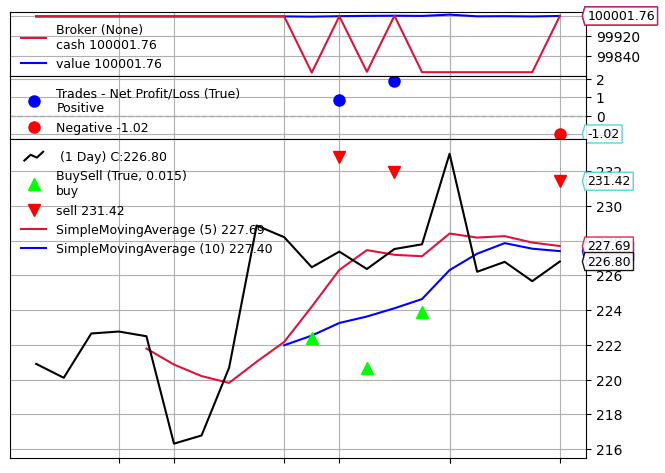

[[<Figure size 640x480 with 3 Axes>]]

In [ ]:
# 繪製結果，確保顯示買賣點
%matplotlib inline
cerebro.plot(iplot=False, volume=False, show=True)

In [ ]:
merged_data

,Open,High,Low,Close,Adj Close,Volume,Sentiment
Date,,,,,,,
2024-09-09,220.820007,221.270004,216.710007,220.910004,220.910004,67180000,0.141057
2024-09-10,218.919998,221.479996,216.729996,220.110001,220.110001,51591000,-0.214150
2024-09-11,221.460007,223.089996,217.889999,222.660004,222.660004,44587100,0.260567
2024-09-12,222.500000,223.550003,219.820007,222.770004,222.770004,37498200,0.293075
2024-09-13,223.580002,224.039993,221.910004,222.500000,222.500000,36766600,0.571000
2024-09-16,216.539993,217.220001,213.919998,216.320007,216.320007,59357400,0.210871
2024-09-17,215.750000,216.899994,214.500000,216.789993,216.789993,45519300,0.236080
2024-09-18,217.550003,222.710007,217.539993,220.690002,220.690002,59894900,0.372567
2024-09-19,224.990005,229.820007,224.630005,228.869995,228.869995,66781300,0.447820
